In [6]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt
import cv2
from torch.utils.data import Dataset, DataLoader
import io
import os
from PIL import Image
import os
import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
import timm

In [7]:
def number_to_filename(number):
    filename = f"{number:06d}.png"
    path = '/kaggle/input/spr-x-ray-gender/kaggle/kaggle/train/'
    filename = path+filename
    return filename

In [ ]:
train_gender_df=pd.read_csv('/kaggle/input/spr-x-ray-gender/train_gender.csv')

In [ ]:
train_gender_df['filepath'] = train_gender_df['imageId'].apply(number_to_filename)

In [5]:
train_gender_df.head(10)

,imageId,gender,filepath
0,0,0,/kaggle/input/spr-x-ray-gender/kaggle/kaggle/t...
1,1,0,/kaggle/input/spr-x-ray-gender/kaggle/kaggle/t...
2,2,1,/kaggle/input/spr-x-ray-gender/kaggle/kaggle/t...
3,3,1,/kaggle/input/spr-x-ray-gender/kaggle/kaggle/t...
4,4,0,/kaggle/input/spr-x-ray-gender/kaggle/kaggle/t...
5,5,1,/kaggle/input/spr-x-ray-gender/kaggle/kaggle/t...
6,6,1,/kaggle/input/spr-x-ray-gender/kaggle/kaggle/t...
7,7,1,/kaggle/input/spr-x-ray-gender/kaggle/kaggle/t...
8,8,0,/kaggle/input/spr-x-ray-gender/kaggle/kaggle/t...
9,9,1,/kaggle/input/spr-x-ray-gender/kaggle/kaggle/t...


<AxesSubplot:>

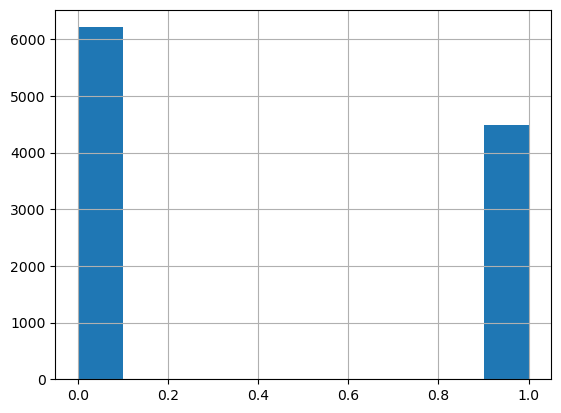

In [6]:
train_gender_df['gender'].hist()

Text(0.5, 1.0, '0')

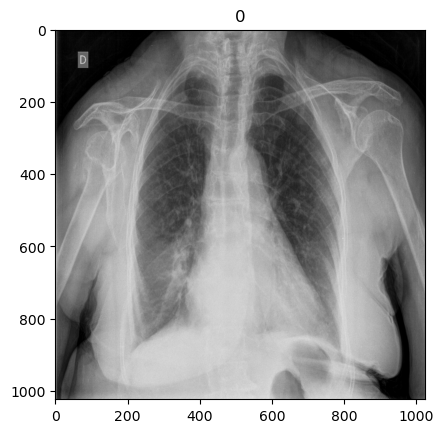

In [7]:
from matplotlib import pyplot as plt
import cv2

img = cv2.imread(train_gender_df['filepath'][0],0)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(str(train_gender_df['gender'][0]))

Text(0.5, 1.0, '0')

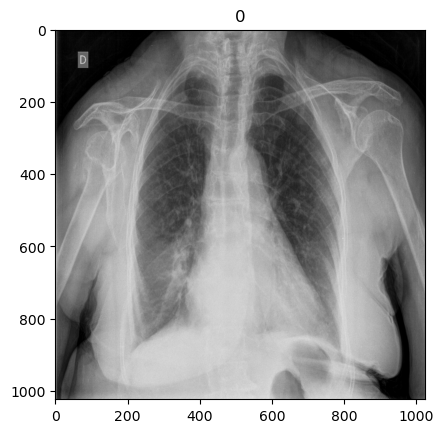

In [8]:
img = cv2.imread(train_gender_df['filepath'][0],0)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(str(train_gender_df['gender'][1]))

In [9]:
from sklearn.model_selection import train_test_split
filenames = train_gender_df['filepath'].tolist()
target = train_gender_df['gender'].tolist()
train_x, val_x, train_y,val_y = train_test_split(filenames, target,stratify=target, test_size=0.05, random_state=0)

In [ ]:
test_df = pd.read_csv('/kaggle/input/spr-x-ray-gender/sample_submission_gender.csv')

In [11]:
def testnumber_to_filename(number):
    filename = f"{number:06d}.png"
    path = '/kaggle/input/spr-x-ray-gender/kaggle/kaggle/test/'
    filename = path+filename
    return filename

In [12]:
test_df['filepath'] = test_df['imageId'].apply(testnumber_to_filename)

In [13]:
test_x= test_df['filepath'].tolist()
test_y = test_df['gender'].tolist()

In [14]:
label2id = {}
id2label = {}
label2id['0'] = str(0)
id2label[str(0)] ='0'

label2id['1'] = str(1)
id2label[str(1)] ='1'


In [15]:
class SPRXrayGenderDataset(torch.utils.data.Dataset):
    def __init__(self, image_files, labels,transforms):
        self.image_files = image_files
        self.labels = labels
        self.transforms = transforms
        
    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, index):
        image_filepath = self.image_files[index]
        image = cv2.imread(image_filepath)
        image = Image.fromarray(image)
    
        return self.transforms(image), self.labels[index]




In [16]:
!pip install torch torchvision timm

In [ ]:


# Set your dataset directory

num_classes = 2  # Number of classes in your dataset
batch_size = 8
image_size = 384

# Load pre-trained EfficientNet model
efficientnet = timm.create_model('efficientnet_b4', pretrained=True, num_classes=num_classes, in_chans=3)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
efficientnet.to(device)

# Create the loss function and optimizer
criterion = nn.CrossEntropyLoss() # predicit - actual label
optimizer = optim.Adam(efficientnet.parameters()) # weights, bias, etc

# Create image transforms for training and validation
train_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(40),
    transforms.RandomAffine(0, shear=10, scale=(0.8, 1.2)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

validation_transforms = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Create data loaders for training and validation
train_dataset = SPRXrayGenderDataset(train_x, train_y, train_transforms)
validation_dataset = SPRXrayGenderDataset(val_x, val_y,validation_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False, num_workers=2)



Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-weights/efficientnet_b4_ra2_320-7eb33cd5.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b4_ra2_320-7eb33cd5.pth


In [ ]:
train_features, train_labels = next(iter(train_loader))
# iter: return batch by batch
# next (): returns first batch only
print(f"Feature batch shape: {train_features.size()}") # (8 3, 384, 384)
print(f"Labels batch shape: {train_labels.size()}") #torch.size([8])
img = train_features[1].squeeze()
img = (img.T).detach().numpy() # img.permute(1,2,0).detach().numpy()
# T is Transpose (e.g. (0, 1, 2) -> (2, 1, 0))
# permute (e.g. (0, 1, 2) -> (1, 2, 0))
label = train_labels[1]
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()
print(f"Label: {label}")

In [ ]:
num_epochs = 5
for epoch in range(num_epochs):
    efficientnet.train()
    running_loss = 0.0
    running_corrects = 0
    
    running_valid_corrects = 0
    running_valid_loss = 0.0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = efficientnet(inputs) # forward
        loss = criterion(outputs, labels)
        _, preds = torch.max(outputs, 1)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = running_corrects.double() / len(train_dataset)

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")
    
    
    efficientnet.eval()
    with torch.no_grad():
        for inputs, labels in validation_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = efficientnet(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            running_valid_loss += loss.item() * inputs.size(0)
            running_valid_corrects += torch.sum(preds == labels.data)
    epoch_loss = running_valid_loss / len(validation_dataset)
    epoch_acc = running_valid_corrects.double() / len(validation_dataset)
    
    print(f"Epoch {epoch + 1}/{num_epochs},Validation Loss: {epoch_loss:.4f}, Validation Accuracy: {epoch_acc:.4f}")
# Save the trained model
torch.save(efficientnet.state_dict(), 'efficientnet_image_classifier.pth')


Epoch 1/5, Loss: 0.2595, Accuracy: 0.9040
Epoch 1/5,Validation Loss: 0.1158, Validation Accuracy: 0.9608
Epoch 2/5, Loss: 0.1448, Accuracy: 0.9529
Epoch 2/5,Validation Loss: 0.0814, Validation Accuracy: 0.9757
Epoch 3/5, Loss: 0.1257, Accuracy: 0.9583
Epoch 3/5,Validation Loss: 0.1254, Validation Accuracy: 0.9590
Epoch 4/5, Loss: 0.1129, Accuracy: 0.9646
Epoch 4/5,Validation Loss: 0.0505, Validation Accuracy: 0.9851
Epoch 5/5, Loss: 0.1077, Accuracy: 0.9643
Epoch 5/5,Validation Loss: 0.1020, Validation Accuracy: 0.9683
